# ML-testbed 08 — infer the machine through several diagnostics

The machine is hidden; diagnostics constrain it. We ask which parameters can be distinguished, then fit several parameters jointly. More channels help only if they add independent information and their calibration is modeled.

## How to use this lesson
Run from the top with **Python (Factor AI)** or the environment in `docs/WORLD_MODEL_COURSE.md`. Each notebook runs independently; later notebooks reuse the small `ml_testbed` package. No API calls or model downloads occur. Training uses the CPU to make the default run portable.

**Skills:** likelihoods, parameter grids, Jacobians, singular values, joint optimization, nuisance parameters

**Evidence contract:** all saved results are exposed synthetic development evidence. Train, tuning, calibration and evaluation draws have separate seeds where used. Re-running and tuning on these evaluation draws makes them development data; they are not a secret final test. Never split frames from one shot across train and evaluation.

**Scope:** a dimensionless, pre-stagnation Z-inspired teaching model. It is not a calibrated digital twin of Sandia's Z machine. The thermal and perturbation variables are proxies; they do not identify phase, ETI, MRTI, or fusion performance.

In [1]:
from pathlib import Path
import sys, json, copy, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from dataclasses import asdict, replace
from IPython.display import display
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'ml_testbed').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the ML-testbed repo, with ml_testbed/ beside notebooks/.')
sys.path.insert(0, str(ROOT))
from ml_testbed.world import *
from ml_testbed.learning import seed_all, fit, save_run, grid_posterior, weighted_interval, entropy
seed_all(42)
plt.rcParams.update({'figure.figsize': (10, 4), 'axes.grid': True, 'grid.alpha': .2})
DEVICE = torch.device('cpu')
print('PyTorch', torch.__version__, '| CPU | dimensionless teaching world v1')

PyTorch 2.14.0 | CPU | dimensionless teaching world v1


## 1. State the inverse problem precisely
For speed, this lesson starts from **12 reconstructed summaries**, not raw waveforms: current, inward speed, radius and thermal proxy, each at three times. `SUMMARY_SIGMA` declares independent Gaussian errors. This is a simplified replacement for the reconstruction layer from lesson 07; its uncertainties are authored, not measured from those reconstructions.

First infer charge and mass with resistance fixed at .22. Growth is absent from these mean-state summaries. Later fit current-channel gain too. These are conditional inferences, not complete inference over every possible uncertainty.

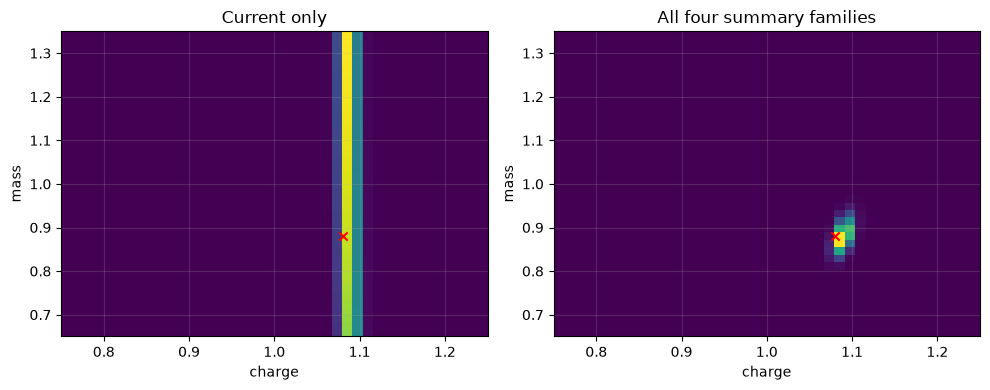

Joint posterior mean: [1.0920398235321045, 0.8782865405082703]


In [2]:
truth=torch.tensor([[1.08,.88,.22,.65]])
seed_all(801)
with torch.no_grad(): obs=summaries(truth)[0]+torch.randn(12)*SUMMARY_SIGMA
current_only=grid_posterior(obs,channels=[0,1,2])
joint=grid_posterior(obs)
fig,axes=plt.subplots(1,2,figsize=(10,4))
for ax,p,title in zip(axes,[current_only,joint],['Current only','All four summary families']):
    ax.imshow(p['weights'].reshape(41,41).T,origin='lower',extent=[.75,1.25,.65,1.35],aspect='auto')
    ax.scatter(float(truth[0,0]),float(truth[0,1]),marker='x',c='red'); ax.set(title=title,xlabel='charge',ylabel='mass')
plt.tight_layout(); plt.show()
print('Joint posterior mean:',joint['mean'][:2].tolist())

### Visual lab — Watch a mass distribution become informative

The shaded areas are marginal probability masses on the discrete mass grid, obtained by summing over charge. The dashed line is evaluator truth. The bands show each model's central 90% interval.

**Notice:** current alone constrains charge much more strongly than mass. A narrow posterior requires measurements that distinguish the remaining alternatives.

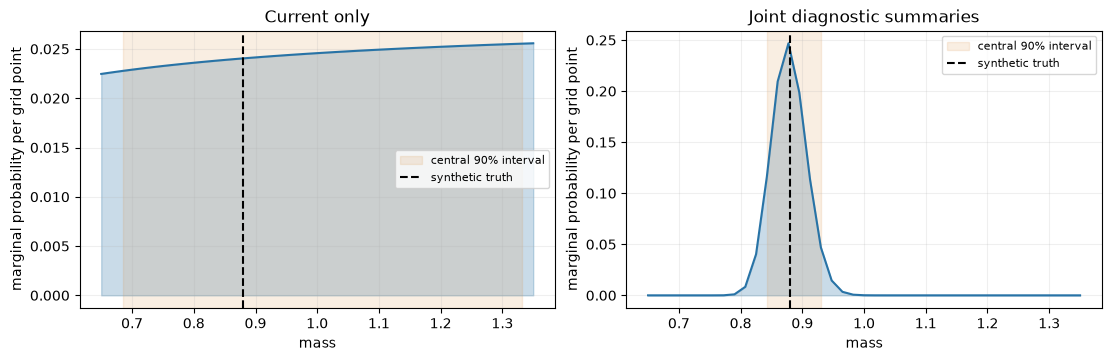

In [3]:
v_fig,v_axes=plt.subplots(1,2,figsize=(11,3.5),layout='constrained')
for v_ax,v_p,v_title in zip(v_axes,[current_only,joint],['Current only','Joint diagnostic summaries']):
    v_m=v_p['m'].numpy(); v_marginal=v_p['weights'].reshape(len(v_p['q']),len(v_m)).sum(0).numpy()
    v_band=weighted_interval(v_p['theta'][:,1],v_p['weights']).numpy()
    v_ax.fill_between(v_m,v_marginal,alpha=.25,color='#2873a6'); v_ax.plot(v_m,v_marginal,color='#2873a6')
    v_ax.axvspan(*v_band,color='#d89042',alpha=.15,label='central 90% interval')
    v_ax.axvline(float(truth[0,1]),color='black',ls='--',label='synthetic truth')
    v_ax.set(title=v_title,xlabel='mass',ylabel='marginal probability per grid point'); v_ax.legend(fontsize=8)
plt.show()

## 2. Inspect local identifiability
A Jacobian measures how observations change with parameters. Dividing by measurement sigma puts changes in noise units; scaling parameter columns by their prior ranges makes singular values more comparable. A zero column means a parameter cannot be inferred through this operator, regardless of optimizer or LM size.

Scaled singular values: [61.197746 23.311014 20.166779  0.      ]
Growth column norm: 0.0


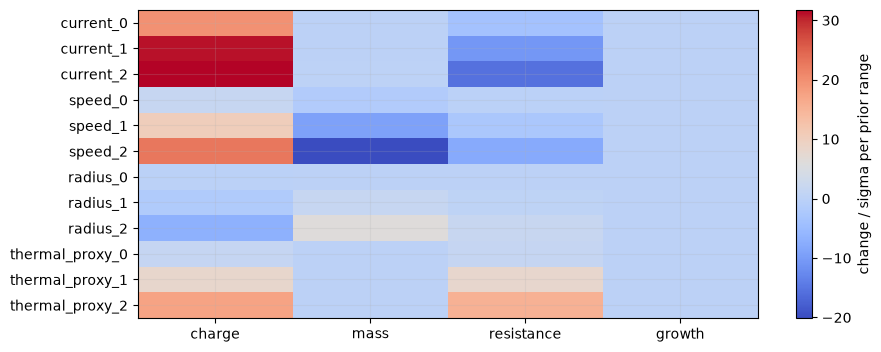

In [4]:
z=truth[0].clone().requires_grad_()
jac=torch.autograd.functional.jacobian(lambda p:summaries(p[None])[0],z)
scaled=jac/SUMMARY_SIGMA[:,None]*torch.tensor(HIGH-LOW)[None,:]
sv=torch.linalg.svdvals(scaled)
print('Scaled singular values:',sv.detach().numpy())
print('Growth column norm:',float(torch.linalg.vector_norm(jac[:,3])))
assert torch.all(jac[:,3]==0)
plt.imshow(scaled.detach().numpy(),aspect='auto',cmap='coolwarm'); plt.xticks(range(4),PARAM_NAMES); plt.yticks(range(12),SUMMARY_NAMES); plt.colorbar(label='change / sigma per prior range'); plt.show()

### Visual lab — Two hidden worlds can produce the same evidence

Only the growth parameter differs between these two worlds. Their current, speed and radius agree exactly under this model, but their perturbations differ.

**Ask:** could a larger LM identify growth from those identical mean-state measurements? The missing information must come from another observable or a justified constraint.

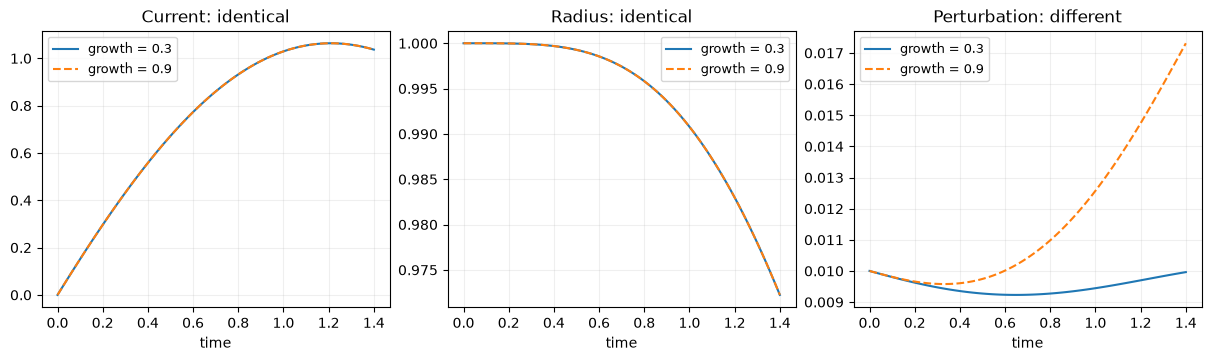

In [5]:
v_twins=truth.repeat(2,1); v_twins[:,3]=torch.tensor([.3,.9])
with torch.no_grad(): v_tt,v_ss=simulate(v_twins)
v_fig,v_axes=plt.subplots(1,3,figsize=(12,3.5),layout='constrained')
for v_j,v_g in enumerate([.3,.9]):
    for v_ax,v_col in zip(v_axes,[1,2,5]): v_ax.plot(v_tt,v_ss[v_j,:,v_col],ls='-' if v_j==0 else '--',label=f'growth = {v_g}')
for v_ax,v_title in zip(v_axes,['Current: identical','Radius: identical','Perturbation: different']):
    v_ax.set(title=v_title,xlabel='time'); v_ax.legend(fontsize=9)
plt.show()

## 3. Fit an uncertain calibration gain
The synthetic current summaries are now multiplied by an unknown gain. Fitting charge alone can absorb calibration error. We fit charge, mass and gain using all channels and a Gaussian gain calibration prior. Resistance remains fixed, and observations are assumed synchronized. Timing uncertainty is treated in the negative control below, not silently optimized away.

Fixed gain: {'charge': 1.1856346130371094, 'mass': 1.072866439819336, 'gain': 1.0, 'loss': 22.994985580444336}
Inferred gain: {'charge': 1.0966209173202515, 'mass': 0.9193795919418335, 'gain': 1.0987162590026855, 'loss': 5.095314025878906}


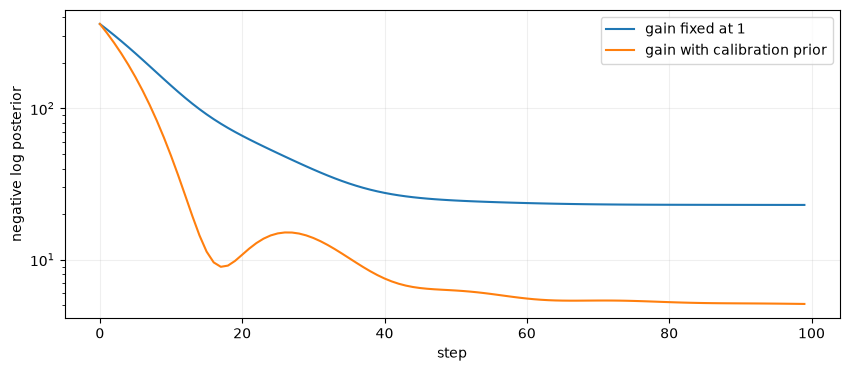

In [6]:
GAIN_TRUE=1.12
with torch.no_grad():
    gain_obs=summaries(truth)[0].clone(); gain_obs[:3]*=GAIN_TRUE
    gain_obs+=torch.randn(12)*SUMMARY_SIGMA

def fit_gain(free_gain=True,steps=100):
    raw=nn.Parameter(torch.zeros(3)); opt=torch.optim.Adam([raw],lr=.06); losses=[]
    for step in range(steps):
        opt.zero_grad()
        charge=.75+.5*torch.sigmoid(raw[0]); mass=.65+.7*torch.sigmoid(raw[1])
        gain=.8+.4*torch.sigmoid(raw[2]) if free_gain else torch.tensor(1.)
        theta=torch.stack([charge,mass,charge*0+.22,charge*0+.6])[None]
        pred=summaries(theta)[0]
        pred=pred*torch.cat([gain.expand(3),torch.ones(9)])
        loss=.5*(((pred-gain_obs)/SUMMARY_SIGMA)**2).sum()+.5*((gain-1)/.15)**2
        loss.backward(); opt.step(); losses.append(float(loss.detach()))
    return {'charge':float(charge.detach()),'mass':float(mass.detach()),'gain':float(gain.detach()),'loss':losses[-1]},losses
fixed,h0=fit_gain(False); free,h1=fit_gain(True)
print('Fixed gain:',fixed); print('Inferred gain:',free)
plt.semilogy(h0,label='gain fixed at 1'); plt.semilogy(h1,label='gain with calibration prior'); plt.xlabel('step'); plt.ylabel('negative log posterior'); plt.legend(); plt.show()

### Visual lab — When calibration error looks like physics

Compare the true parameter values with both optimization results. In the fixed-gain fit, charge and mass can move to compensate for the wrong gain. Allowing gain to vary with a prior reduces that confounding for this example.

**Notice:** a successful optimizer can return biased machine parameters if its instrument model is wrong.

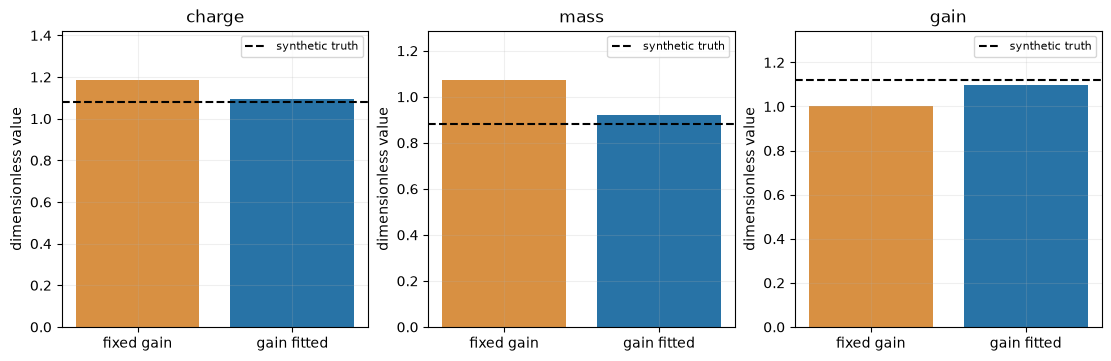

In [7]:
v_truths=[float(truth[0,0]),float(truth[0,1]),GAIN_TRUE]
v_fig,v_axes=plt.subplots(1,3,figsize=(11,3.5),layout='constrained')
for v_j,(v_ax,v_name) in enumerate(zip(v_axes,['charge','mass','gain'])):
    v_ax.bar(['fixed gain','gain fitted'],[fixed[v_name],free[v_name]],color=['#d89042','#2873a6'])
    v_ax.axhline(v_truths[v_j],color='black',ls='--',label='synthetic truth')
    v_ax.set(title=v_name,ylabel='dimensionless value',ylim=(0,max(v_truths[v_j],fixed[v_name],free[v_name])*1.2)); v_ax.legend(fontsize=8)
plt.show()

## 4. A timing nuisance creates correlated errors
A clock shift changes many samples together. Here we linearize its contribution as $\Sigma = D + \sigma_t^2 jj^T$, where $j=dy/dt$. This covariance is local and first-order. For a large shift, nonlinear delay fitting would be needed. Independent-error likelihoods can overstate the amount of information.

Mass interval ignoring shared timing: [0.8075000047683716, 0.8949999809265137]
Mass interval including timing covariance: [0.824999988079071, 0.9300000071525574]


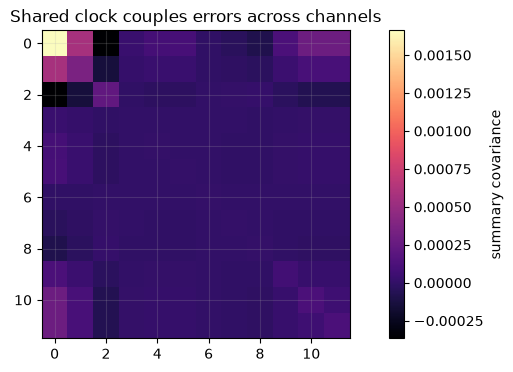

In [8]:
tt,ss=simulate(truth); ids=[32,64,95]
derivative=torch.gradient(ss[0],spacing=(tt,),dim=0)[0]
jtime=torch.cat([derivative[ids,j] for j in (1,3,2,4)])
clock_sigma=.035
cov=torch.diag(SUMMARY_SIGMA.square())+clock_sigma**2*torch.outer(jtime,jtime)
shifted_obs=obs+.05*jtime
pred=joint['predictions']; residual=pred-shifted_obs
logp=-.5*(residual*torch.linalg.solve(cov,residual.T).T).sum(1)
wc=torch.softmax(logp,0)
naive=grid_posterior(shifted_obs)
print('Mass interval ignoring shared timing:',weighted_interval(naive['theta'][:,1],naive['weights']).tolist())
print('Mass interval including timing covariance:',weighted_interval(joint['theta'][:,1],wc).tolist())
plt.imshow(cov.numpy(),cmap='magma'); plt.colorbar(label='summary covariance'); plt.title('Shared clock couples errors across channels'); plt.show()

## 5. Ask whether the assumed model predicts the observations
Posterior predictive residuals are a model check. They are not independent validation because these data were used to fit. A discrepancy can arise from wrong physics, calibration, noise assumptions, or reconstruction errors. A small residual does not establish that the model is unique.

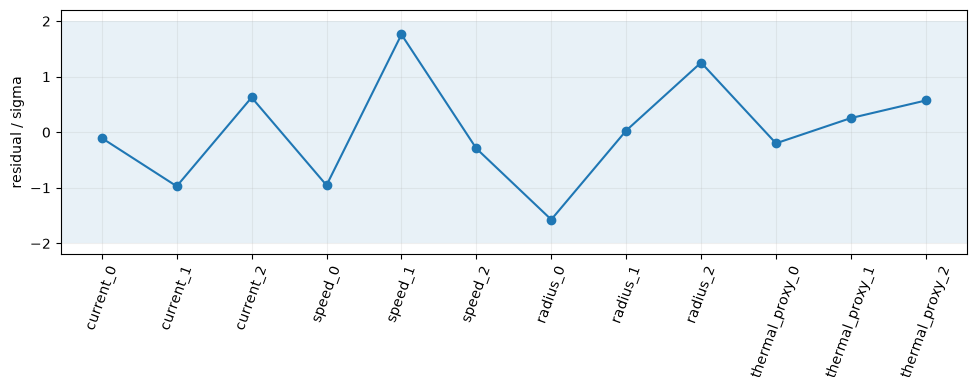

/Users/operator/Desktop/Factor/runs/world-model/08-62e511c98a


In [9]:
mean_prediction=(joint['weights'][:,None]*joint['predictions']).sum(0)
res=(obs-mean_prediction)/SUMMARY_SIGMA
plt.axhspan(-2,2,alpha=.1); plt.plot(res,'o-'); plt.xticks(range(12),SUMMARY_NAMES,rotation=70); plt.ylabel('residual / sigma'); plt.tight_layout(); plt.show()
run=save_run(ROOT,'08',{'posterior_mean':joint['mean'].tolist(),'scaled_singular_values':sv.tolist(),
                       'fixed_gain_fit':fixed,'free_gain_fit':free,'max_standardized_residual':float(res.abs().max())},
             {'likelihood':'reconstructed summaries, independent Gaussian except timing control','resistance_fixed':.22})
print(run)

## Your next experiments

Write a prediction, change one thing, and save both successes and failures.

1. Add an image-derived perturbation summary. Does the growth column become nonzero, and is it still confused with seed amplitude?
2. Jointly fit resistance and current gain. Plot the tradeoff before choosing a larger network.
3. Replace the linearized timing covariance with an explicit latent clock offset and compare inferred uncertainty.